# 01 — Exploratory Data Analysis & Revenue Insights

**Hotel Booking Demand Dataset** (119,390 bookings | 2015–2017)  
This notebook covers data cleaning, feature engineering, and in-depth revenue & cancellation analysis.

---

## 1. Setup & Data Loading

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.config import COLORS, CATEGORY_PALETTE, GOLD_PALETTE, MONTH_ORDER, DATA_PATH, FIGURES_PATH
from src.data_cleaning import load_raw_data, clean_data, get_data_summary
from src.feature_engineering import add_features
from src.viz_style import set_theme, format_axis_currency, format_axis_pct, add_value_labels

set_theme()
print('Setup complete.')

Setup complete.


In [2]:
# Load raw data
raw = load_raw_data(DATA_PATH)
print(f'Raw data shape: {raw.shape}')
raw.head()

Raw data shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Data Overview

In [3]:
# Data types and missing values
info_df = pd.DataFrame({
    'dtype': raw.dtypes,
    'non_null': raw.notnull().sum(),
    'null_count': raw.isnull().sum(),
    'null_pct': (raw.isnull().sum() / len(raw) * 100).round(2),
    'unique': raw.nunique()
})
info_df[info_df['null_count'] > 0]

,dtype,non_null,null_count,null_pct,unique
children,float64,119386,4,0.00,5
country,object,118902,488,0.41,177
agent,float64,103050,16340,13.69,333
company,float64,6797,112593,94.31,352


In [4]:
# Check for 'NULL' strings in agent/company columns
for col in ['agent', 'company', 'country']:
    null_str_count = (raw[col] == 'NULL').sum() if raw[col].dtype == 'object' else 0
    print(f'{col}: {null_str_count} "NULL" strings, {raw[col].isnull().sum()} NaN')

agent: 0 "NULL" strings, 16340 NaN
company: 0 "NULL" strings, 112593 NaN
country: 0 "NULL" strings, 488 NaN


## 3. Data Cleaning & Feature Engineering

In [5]:
# Clean data
df = clean_data(raw)
print(f'After cleaning: {df.shape}')

# Add engineered features
df = add_features(df)
print(f'After feature engineering: {df.shape}')

# Verify: no negative ADR, critical columns have no nulls
assert (df['adr'] >= 0).all(), 'Negative ADR found!'
assert df['arrival_date'].notnull().all(), 'Missing arrival_date found!'
print('\nValidation passed.')

After cleaning: (119388, 34)
After feature engineering: (119388, 55)

Validation passed.


In [6]:
# Quick summary
summary = get_data_summary(df)
print(f"Rows: {summary['shape'][0]:,}  |  Columns: {summary['shape'][1]}")
print(f"Cancellation Rate: {summary['canceled_pct']:.1f}%")
df.describe().round(2)

Rows: 119,388  |  Columns: 55
Cancellation Rate: 37.0%


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,lead_time_squared,adr_per_person,stays_ratio,is_long_stay,has_company,has_agent,booking_changes_flag,waiting_list_flag,net_previous_bookings,cancel_history_ratio
count,119388.00,119388.00,119388.00,119388.00,119388.00,119388.00,119388.00,119388.00,119388.0,119388.00,...,119388.00,119388.00,119388.00,119388.00,119388.00,119388.00,119388.00,119388.00,119388.00,119388.00
mean,0.37,104.01,2016.16,27.17,15.80,0.93,2.50,1.86,0.1,0.01,...,22238.04,54.90,0.25,0.12,0.06,0.86,0.15,0.03,0.05,0.05
min,0.00,0.00,2015.00,1.00,1.00,0.00,0.00,0.00,0.0,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-26.00,0.00
25%,0.00,18.00,2016.00,16.00,8.00,0.00,1.00,2.00,0.0,0.00,...,324.00,37.40,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
50%,0.00,69.00,2016.00,28.00,16.00,1.00,2.00,2.00,0.0,0.00,...,4761.00,49.50,0.25,0.00,0.00,1.00,0.00,0.00,0.00,0.00
75%,1.00,160.00,2017.00,38.00,23.00,2.00,3.00,2.00,0.0,0.00,...,25600.00,66.00,0.40,0.00,0.00,1.00,0.00,0.00,0.00,0.00
max,1.00,737.00,2017.00,53.00,31.00,19.00,50.00,55.00,10.0,10.00,...,543169.00,510.00,1.00,1.00,1.00,1.00,1.00,1.00,66.00,1.00
std,0.48,106.86,0.71,13.61,8.78,1.00,1.91,0.58,0.4,0.10,...,40741.70,28.09,0.28,0.32,0.23,0.34,0.36,0.17,1.60,0.22


---
## 4. Revenue Overview Dashboard

In [7]:
# Key metrics
total_rev = df['total_revenue'].sum()
lost_rev = df['revenue_lost'].sum()
actual_rev = total_rev - lost_rev
cancel_rate = df['is_canceled'].mean()

print(f"Total Potential Revenue:  ${total_rev:,.0f}")
print(f"Revenue Lost (Canceled):  ${lost_rev:,.0f} ({lost_rev/total_rev*100:.1f}%)")
print(f"Actual Revenue:           ${actual_rev:,.0f}")
print(f"Overall Cancellation Rate: {cancel_rate:.1%}")

Total Potential Revenue:  $42,718,161
Revenue Lost (Canceled):  $16,721,837 (39.1%)
Actual Revenue:           $25,996,324
Overall Cancellation Rate: 37.0%


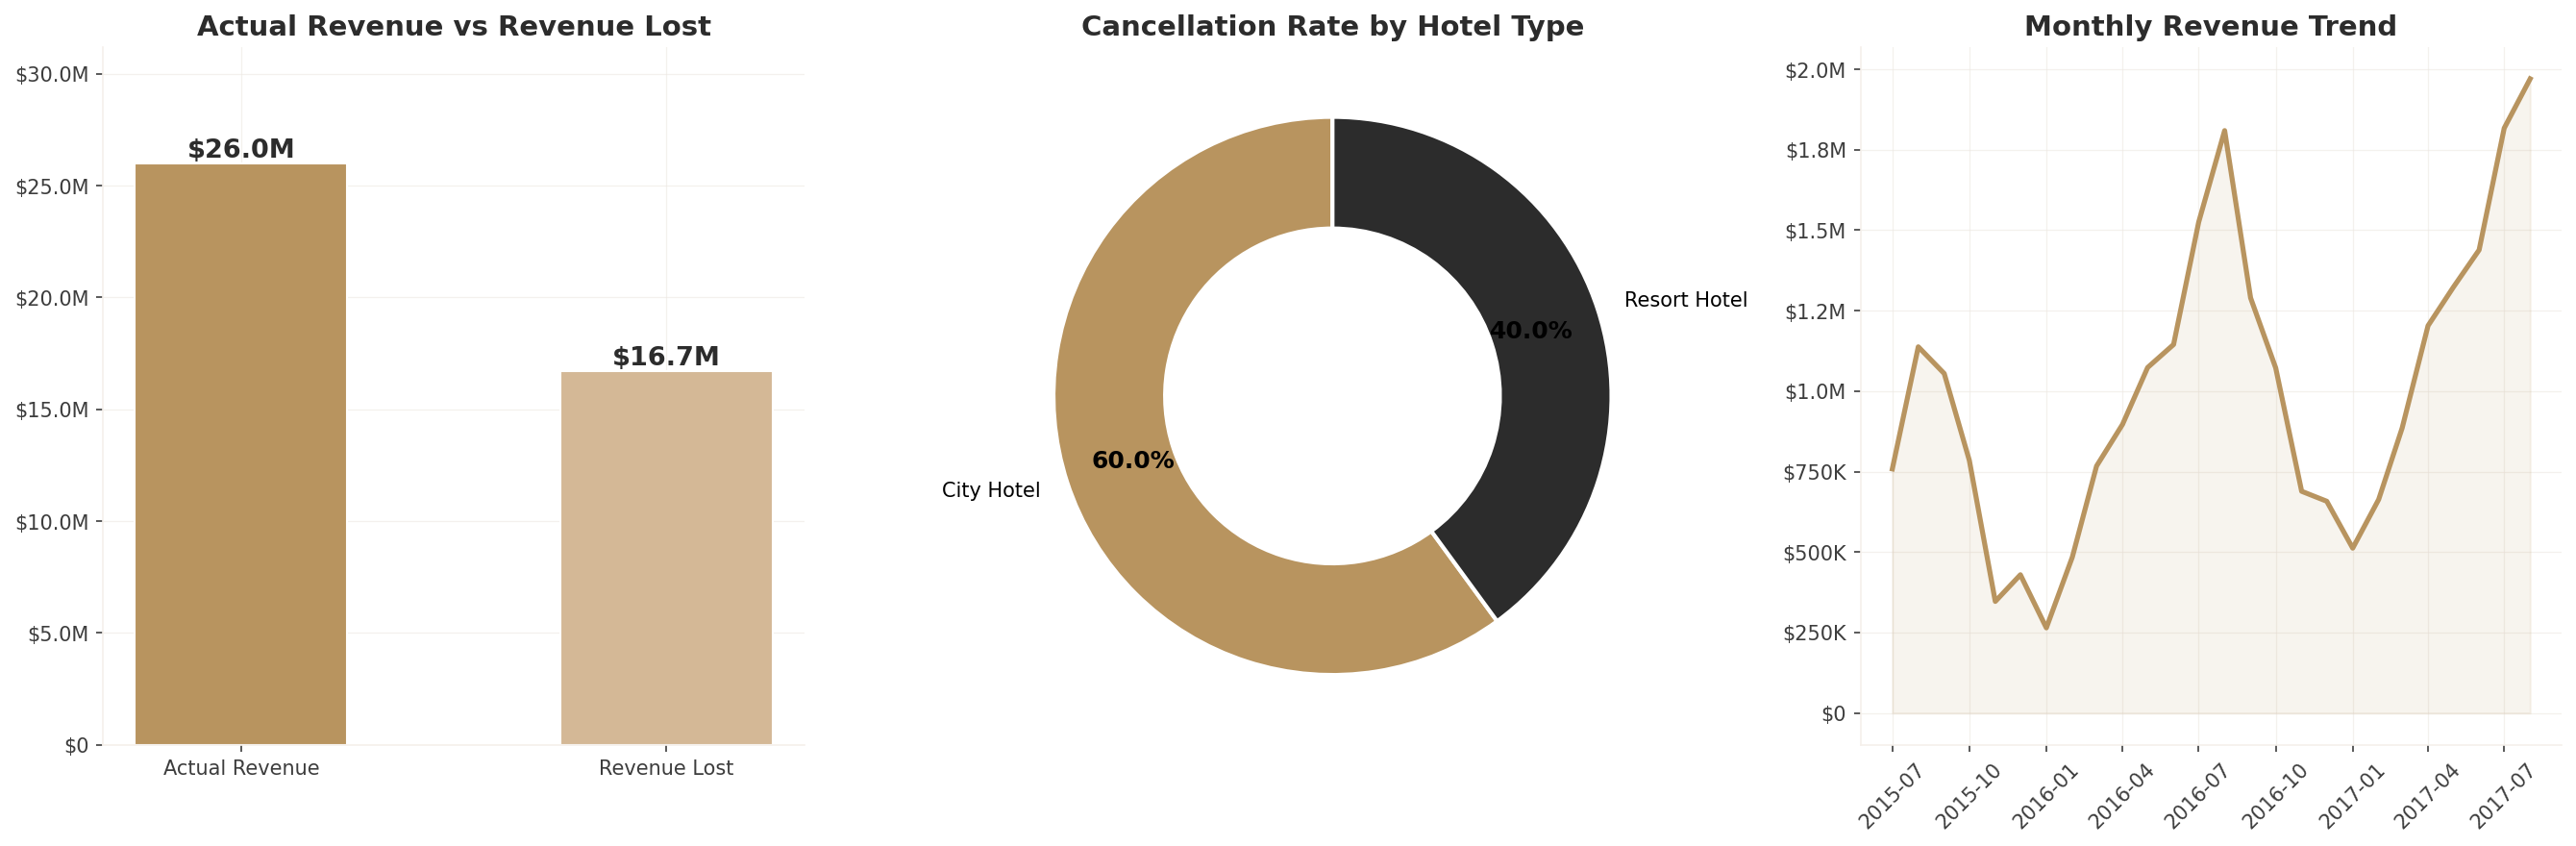

In [8]:
# 4.1 — Total Revenue vs Revenue Lost
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Bar chart: Revenue comparison
ax = axes[0]
bars = ax.bar(
    ['Actual Revenue', 'Revenue Lost'],
    [actual_rev, lost_rev],
    color=[COLORS['primary'], COLORS['accent']],
    width=0.5,
    edgecolor='white'
)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h, f'${h/1e6:.1f}M',
            ha='center', va='bottom', fontsize=13, fontweight='bold', color=COLORS['dark'])
ax.set_title('Actual Revenue vs Revenue Lost', fontsize=14, fontweight='bold')
format_axis_currency(ax)
ax.set_ylim(0, max(actual_rev, lost_rev) * 1.2)

# Donut chart: Cancellation rate by hotel type
ax = axes[1]
cancel_by_hotel = df.groupby('hotel')['is_canceled'].mean()
colors_donut = [COLORS['primary'], COLORS['dark']]
wedges, texts, autotexts = ax.pie(
    cancel_by_hotel,
    labels=cancel_by_hotel.index,
    autopct='%1.1f%%',
    colors=colors_donut,
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts:
    t.set_fontsize(12)
    t.set_fontweight('bold')
ax.set_title('Cancellation Rate by Hotel Type', fontsize=14, fontweight='bold')

# Monthly revenue trend
ax = axes[2]
monthly = df[df['is_canceled'] == 0].groupby(
    [df['arrival_date'].dt.to_period('M')]
)['total_revenue'].sum().reset_index()
monthly.columns = ['month', 'revenue']
monthly['month'] = monthly['month'].dt.to_timestamp()
ax.plot(monthly['month'], monthly['revenue'], color=COLORS['primary'], linewidth=2.5)
ax.fill_between(monthly['month'], monthly['revenue'], alpha=0.1, color=COLORS['primary'])
ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
format_axis_currency(ax)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}01_revenue_overview.png')
plt.show()

---
## 5. Revenue Deep Dive

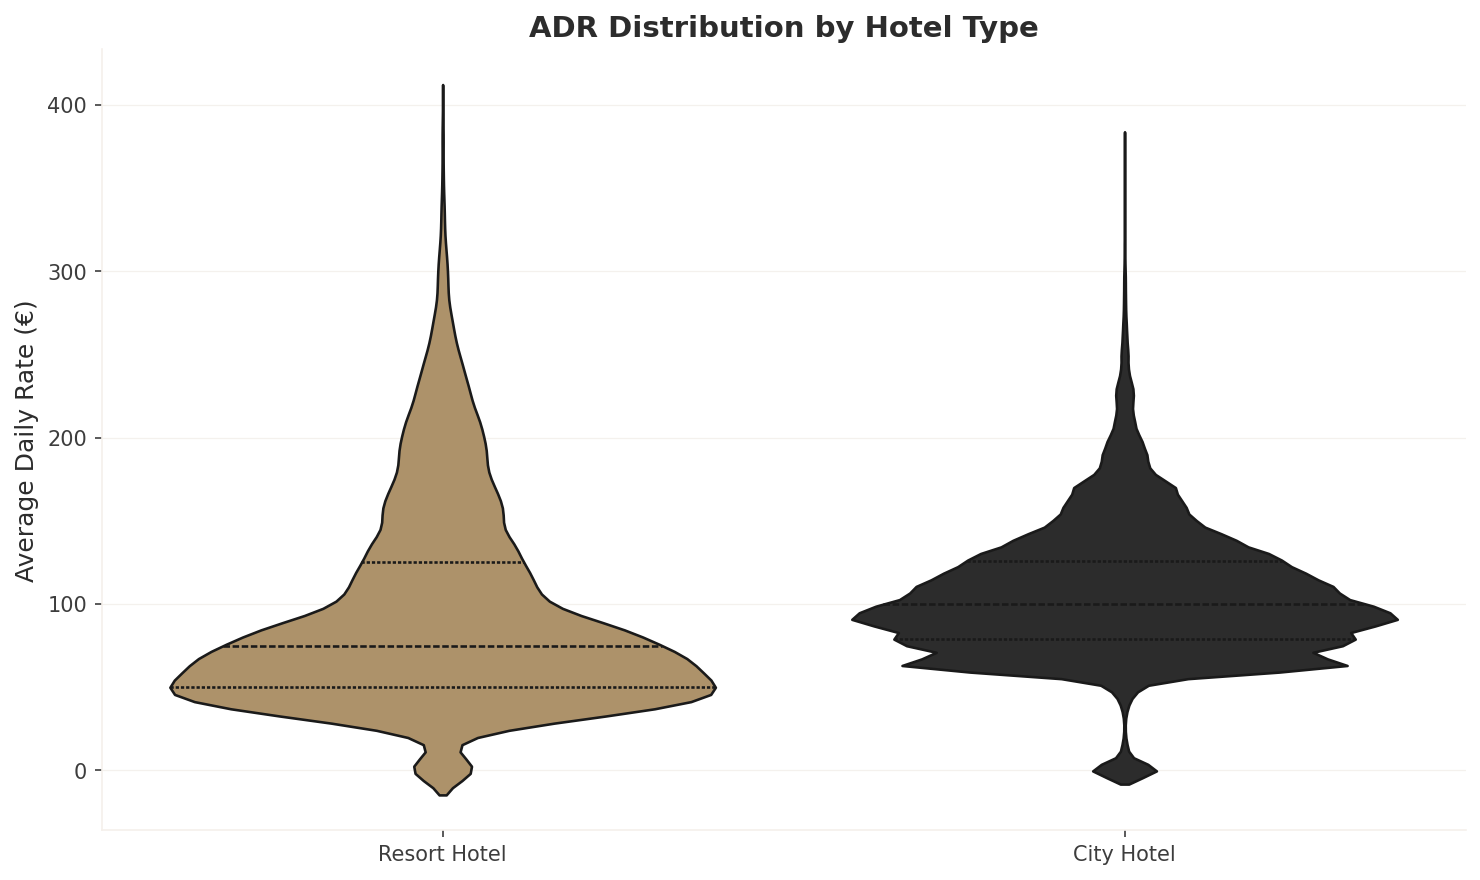

In [9]:
# 5.1 — ADR Distribution by Hotel Type (Violin Plot)
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(
    data=df[df['adr'] < 400],
    x='hotel', y='adr',
    palette=[COLORS['primary'], COLORS['dark']],
    inner='quartile',
    ax=ax
)
ax.set_title('ADR Distribution by Hotel Type', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Average Daily Rate (€)')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}02_adr_violin.png')
plt.show()

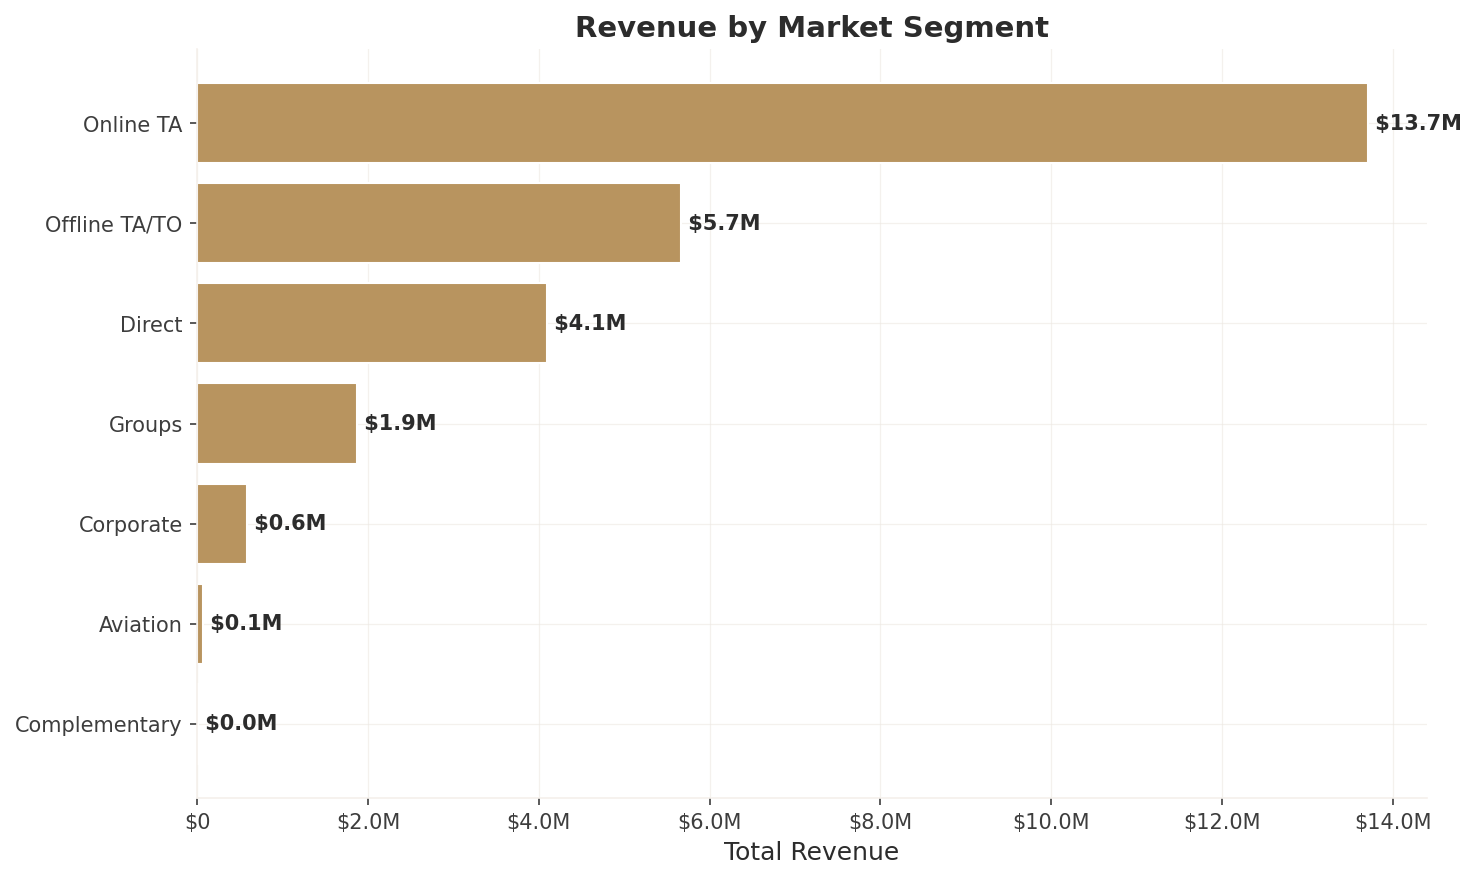

In [10]:
# 5.2 — Revenue by Market Segment (Horizontal Bar)
rev_by_segment = (
    df[df['is_canceled'] == 0]
    .groupby('market_segment')['total_revenue']
    .sum()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    rev_by_segment.index,
    rev_by_segment.values,
    color=COLORS['primary'],
    edgecolor='white'
)
for bar in bars:
    w = bar.get_width()
    ax.text(w, bar.get_y() + bar.get_height()/2, f' ${w/1e6:.1f}M',
            ha='left', va='center', fontsize=10, fontweight='bold', color=COLORS['dark'])
ax.set_title('Revenue by Market Segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue')
format_axis_currency(ax, axis='x')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}03_revenue_by_segment.png')
plt.show()

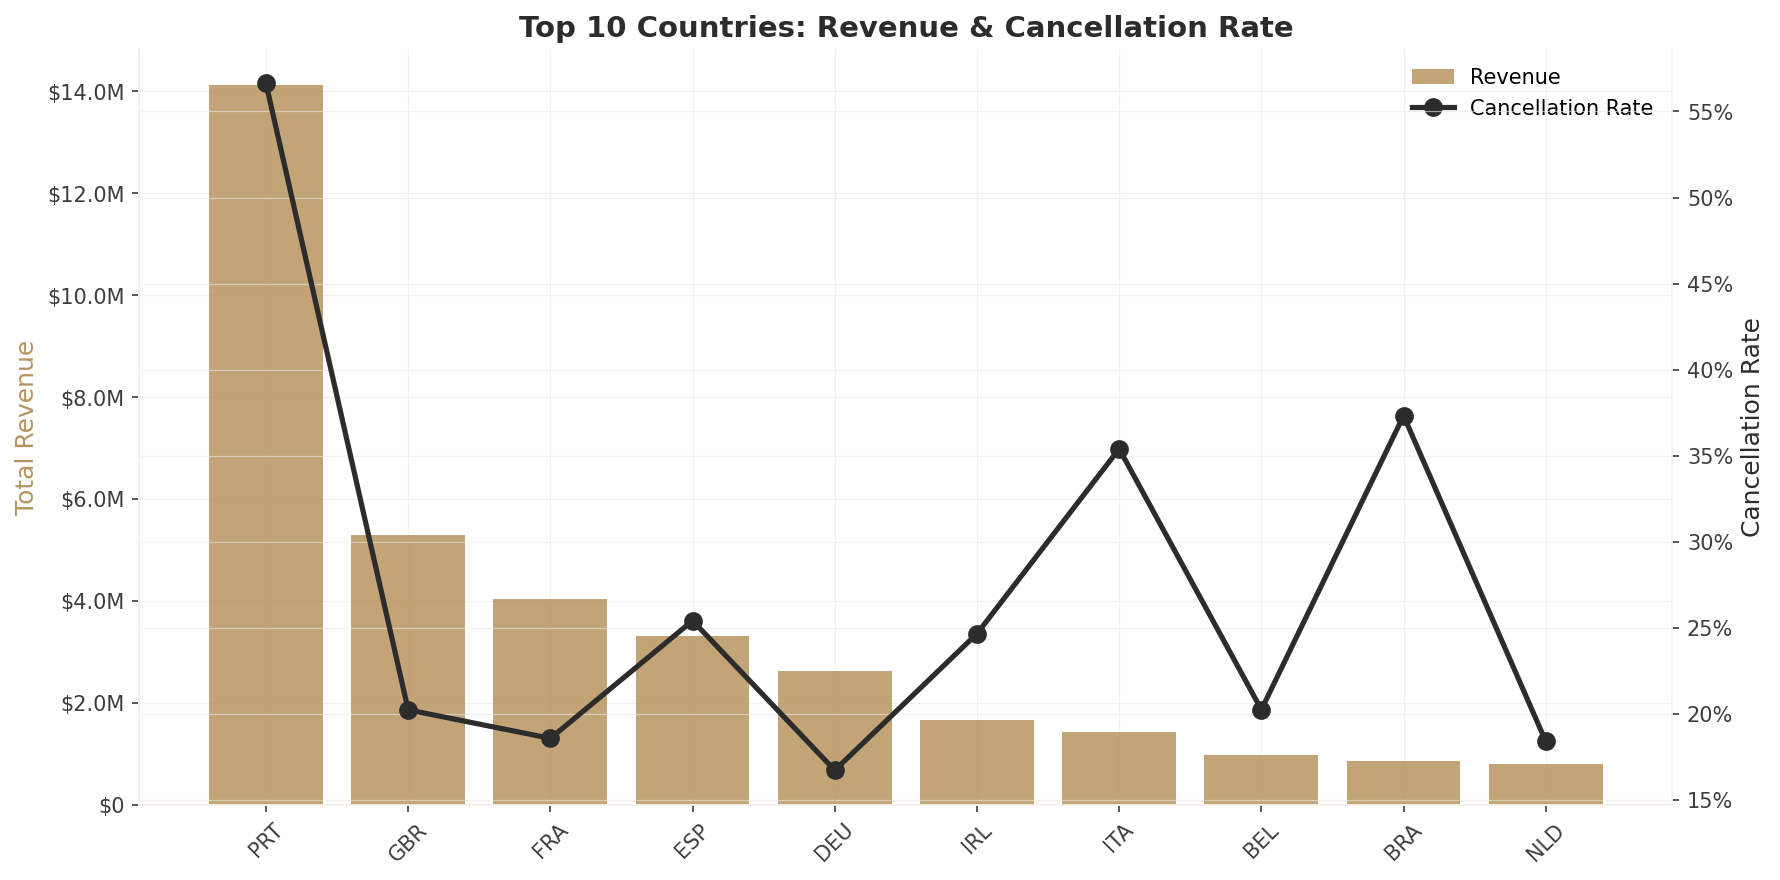

In [11]:
# 5.3 — Top 10 Countries by Revenue with Cancellation Overlay
country_stats = df.groupby('country').agg(
    total_revenue=('total_revenue', 'sum'),
    cancel_rate=('is_canceled', 'mean'),
    bookings=('is_canceled', 'count')
).sort_values('total_revenue', ascending=False).head(10)

fig, ax1 = plt.subplots(figsize=(12, 6))
x = range(len(country_stats))
ax1.bar(x, country_stats['total_revenue'], color=COLORS['primary'], alpha=0.85, label='Revenue')
ax1.set_ylabel('Total Revenue', color=COLORS['primary'])
format_axis_currency(ax1)
ax1.set_xticks(x)
ax1.set_xticklabels(country_stats.index, rotation=45)

ax2 = ax1.twinx()
ax2.plot(x, country_stats['cancel_rate'], color=COLORS['dark'], marker='o',
         linewidth=2.5, markersize=8, label='Cancellation Rate')
ax2.set_ylabel('Cancellation Rate', color=COLORS['dark'])
format_axis_pct(ax2)
ax2.spines['right'].set_visible(True)

ax1.set_title('Top 10 Countries: Revenue & Cancellation Rate', fontsize=14, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}04_top_countries.png')
plt.show()

---
## 6. Cancellation Pattern Analysis

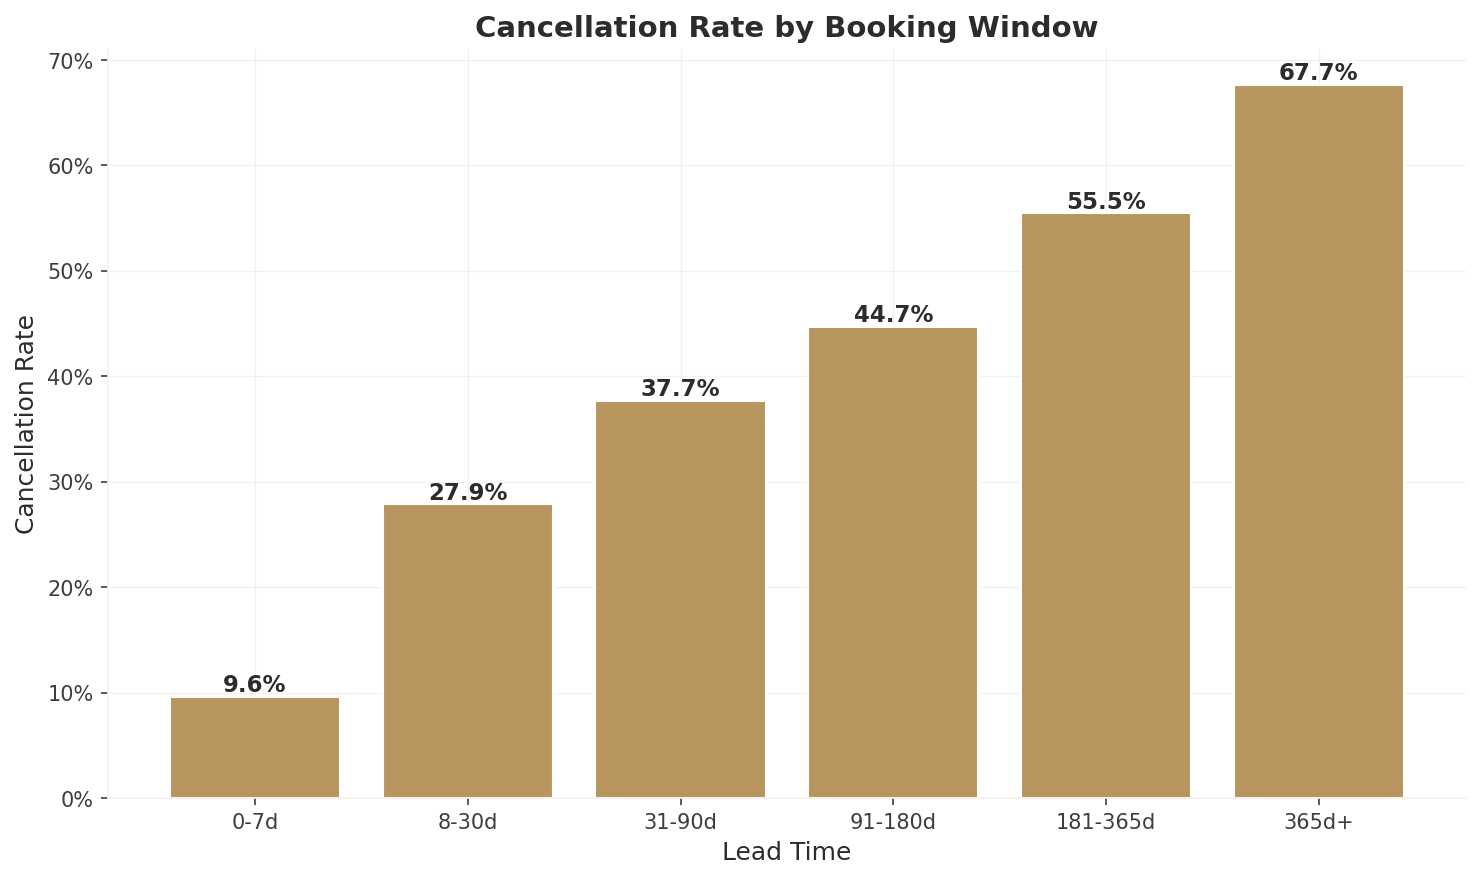

In [12]:
# 6.1 — Cancellation Rate by Lead Time Bucket
cancel_by_lead = df.groupby('booking_window', observed=False)['is_canceled'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(cancel_by_lead.index.astype(str), cancel_by_lead.values,
              color=COLORS['primary'], edgecolor='white')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h, f'{h:.1%}',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color=COLORS['dark'])
ax.set_title('Cancellation Rate by Booking Window', fontsize=14, fontweight='bold')
ax.set_xlabel('Lead Time')
ax.set_ylabel('Cancellation Rate')
format_axis_pct(ax)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}05_cancel_by_leadtime.png')
plt.show()

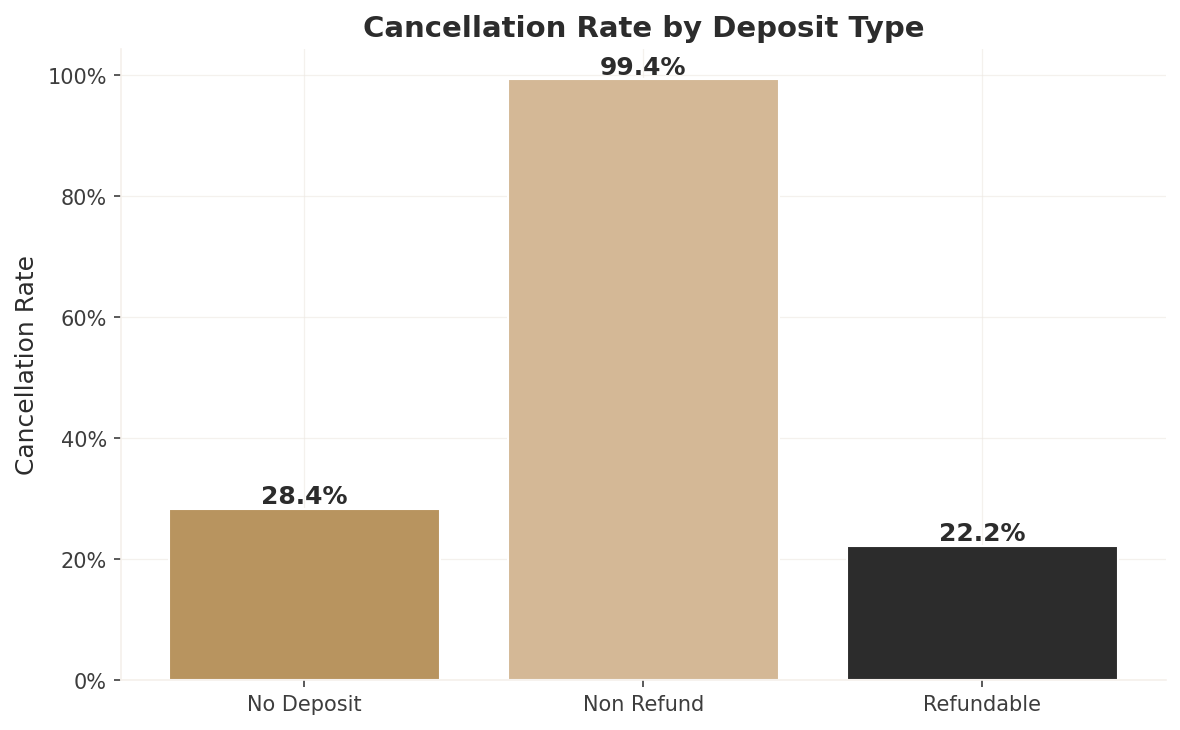

In [13]:
# 6.2 — Cancellation vs Deposit Type
deposit_cancel = df.groupby('deposit_type')['is_canceled'].agg(['mean', 'count']).reset_index()
deposit_cancel.columns = ['deposit_type', 'cancel_rate', 'bookings']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(deposit_cancel['deposit_type'], deposit_cancel['cancel_rate'],
              color=[COLORS['primary'], COLORS['accent'], COLORS['dark']], edgecolor='white')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h, f'{h:.1%}',
            ha='center', va='bottom', fontsize=12, fontweight='bold', color=COLORS['dark'])
ax.set_title('Cancellation Rate by Deposit Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Cancellation Rate')
format_axis_pct(ax)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}06_cancel_by_deposit.png')
plt.show()

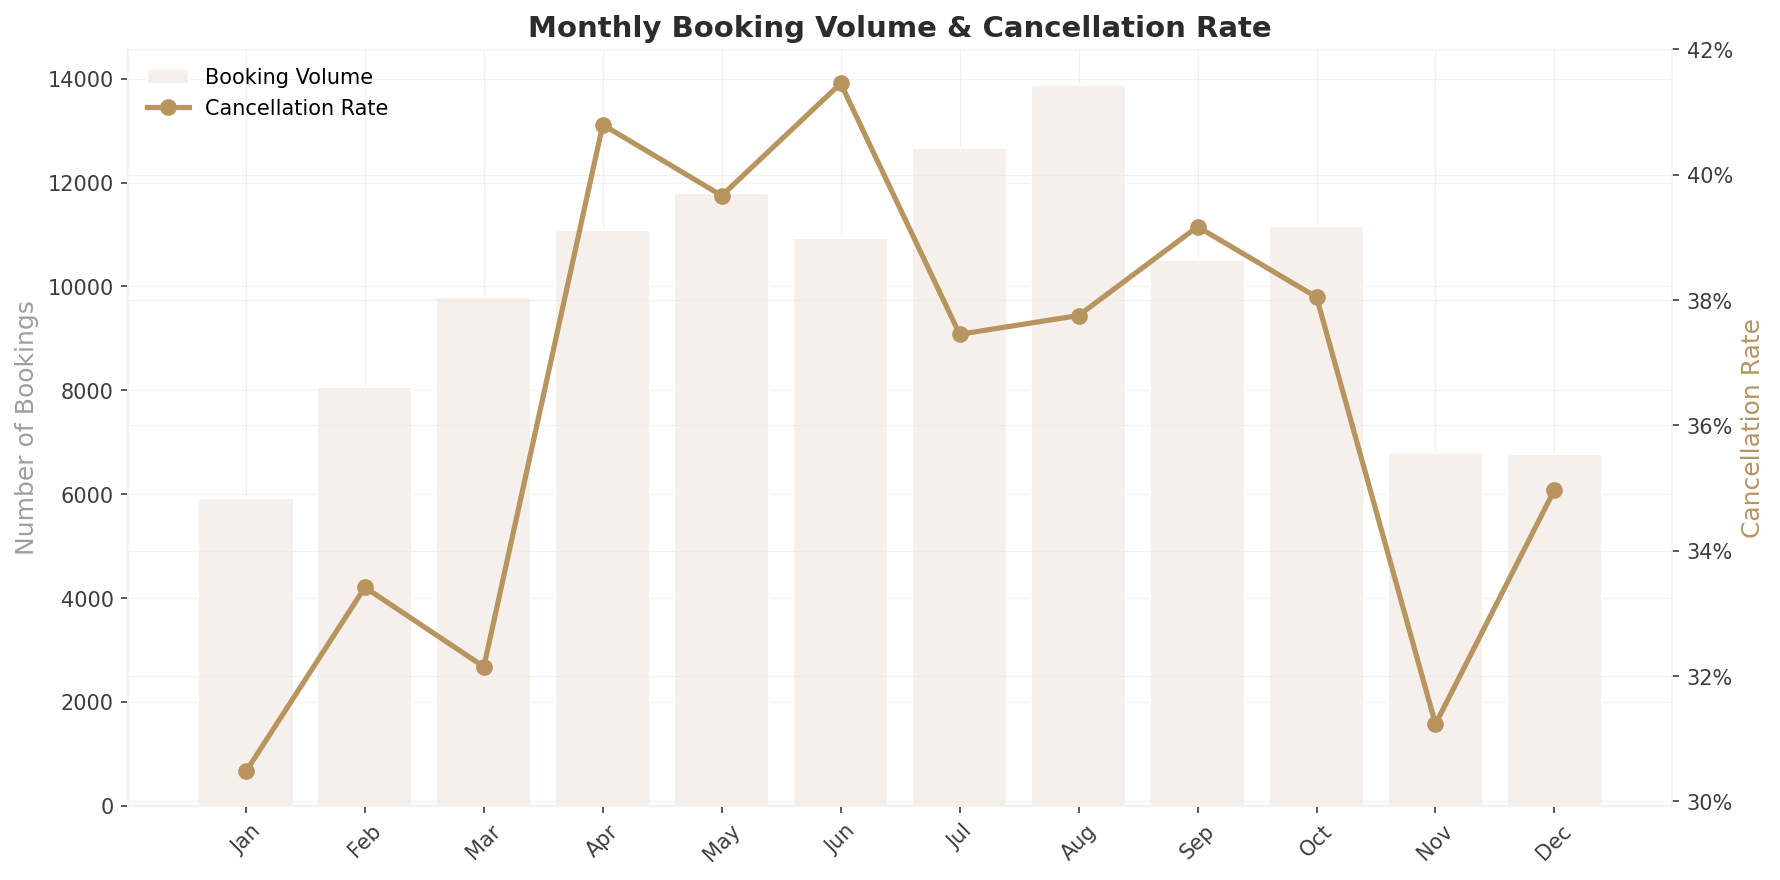

In [14]:
# 6.3 — Cancellation Rate & Booking Volume by Month (Dual Axis)
monthly_cancel = df.groupby('arrival_date_month').agg(
    cancel_rate=('is_canceled', 'mean'),
    bookings=('is_canceled', 'count')
).reindex(MONTH_ORDER)

fig, ax1 = plt.subplots(figsize=(12, 6))
x = range(len(MONTH_ORDER))
ax1.bar(x, monthly_cancel['bookings'], color=COLORS['light_gray'], edgecolor='white', label='Booking Volume')
ax1.set_ylabel('Number of Bookings', color=COLORS['muted'])
ax1.set_xticks(x)
ax1.set_xticklabels([m[:3] for m in MONTH_ORDER], rotation=45)

ax2 = ax1.twinx()
ax2.plot(x, monthly_cancel['cancel_rate'], color=COLORS['primary'], marker='o',
         linewidth=2.5, markersize=7, label='Cancellation Rate')
ax2.set_ylabel('Cancellation Rate', color=COLORS['primary'])
format_axis_pct(ax2)
ax2.spines['right'].set_visible(True)

ax1.set_title('Monthly Booking Volume & Cancellation Rate', fontsize=14, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}07_monthly_cancel_trend.png')
plt.show()

---
## 7. Key Business Insights

### Revenue Impact
- **Cancellations represent a significant revenue risk** — a large portion of potential revenue is lost to cancellations, impacting both Resort and City Hotels.
- **Online TA and Groups** are the top revenue-generating market segments, but they also carry higher cancellation rates.
- **Portugal** leads in total bookings and revenue, but also has one of the highest cancellation rates among top countries.

### Cancellation Patterns
- **Lead time is the strongest predictor** — cancellation rate increases dramatically with longer booking windows (365d+ has the highest rate).
- **Non-refundable deposits** paradoxically show higher cancellation rates, suggesting these are used by segments that are more price-sensitive or comparison-shopping.
- **Seasonal pattern**: Summer months see both peak bookings and elevated cancellation rates.

### Strategic Recommendations
1. **Implement tiered overbooking strategy** based on lead time — higher overbooking for long lead-time bookings.
2. **Dynamic deposit policies** — require deposits for high-risk segments (long lead time + Online TA).
3. **Revenue recovery program** — proactive re-engagement for bookings with high cancellation probability.

---
*Next: [02_Cancellation_Prediction.ipynb](02_Cancellation_Prediction.ipynb) — Building a predictive model for cancellations.*